# Recherche informée

CSI 4106 - Automne 2024

Marcel Turcotte  
Version: nov. 22, 2024 09h02

# Préambule

## Citation du jour

## Objectifs d’apprentissage

-   **Comprendre** les stratégies de recherche informée et le rôle des
    fonctions heuristiques dans l’efficacité de la recherche.

-   **Implémenter** et comparer BFS, DFS, et la recherche par meilleur
    choix (Best-First Search) en utilisant le problème du puzzle à 8
    cases.

-   **Analyser** la performance et l’optimalité de divers algorithmes de
    recherche.

# Résumé

## Problème de recherche

-   Un ensemble d’**états**, appelé **espace d’états**.

-   Un **état initial** où l’agent commence.

-   Un ou plusieurs **états objectifs** qui définissent des résultats
    réussis.

-   Un ensemble d’**actions** disponibles dans un état donné $s$.

-   Un **modèle de transition** qui détermine l’état suivant en fonction
    de l’état actuel et de l’action sélectionnée.

-   Une **fonction de coût d’action** qui spécifie le coût de
    l’exécution de l’action $a$ dans l’état $s$ pour atteindre l’état
    $s'$.

## Définitions

-   Un **chemin** est défini comme une séquence d’actions.

-   Une **solution** est un chemin qui relie l’état initial à l’état
    objectif.

-   Une **solution optimale** est le chemin avec le coût le plus bas
    parmi toutes les solutions possibles.

Nous supposons que le **coût du chemin** est la somme des coûts
individuels des actions, et que tous les coûts sont positifs. L’espace
d’états peut être conceptualisé comme un **graphe**, où les nœuds
représentent les états et les arêtes correspondent aux actions.

Dans certains problèmes, plusieurs solutions optimales peuvent exister.
Cependant, il est généralement suffisant d’identifier et de rapporter
une seule solution optimale. Fournir toutes les solutions optimales peut
considérablement augmenter la complexité en temps et en espace pour
certains problèmes.

## Exemple : 8-Puzzle

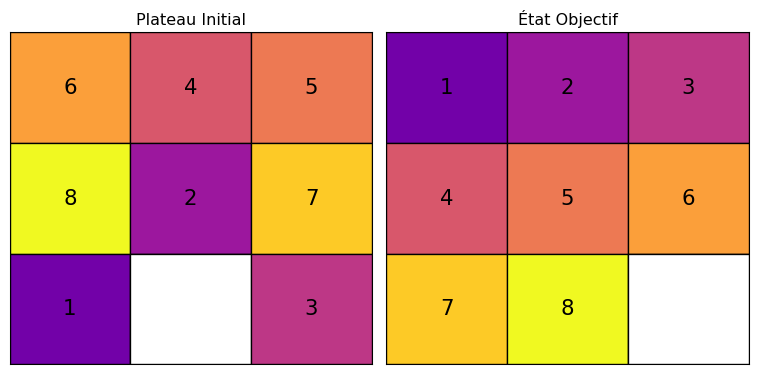

## Arbre de recherche

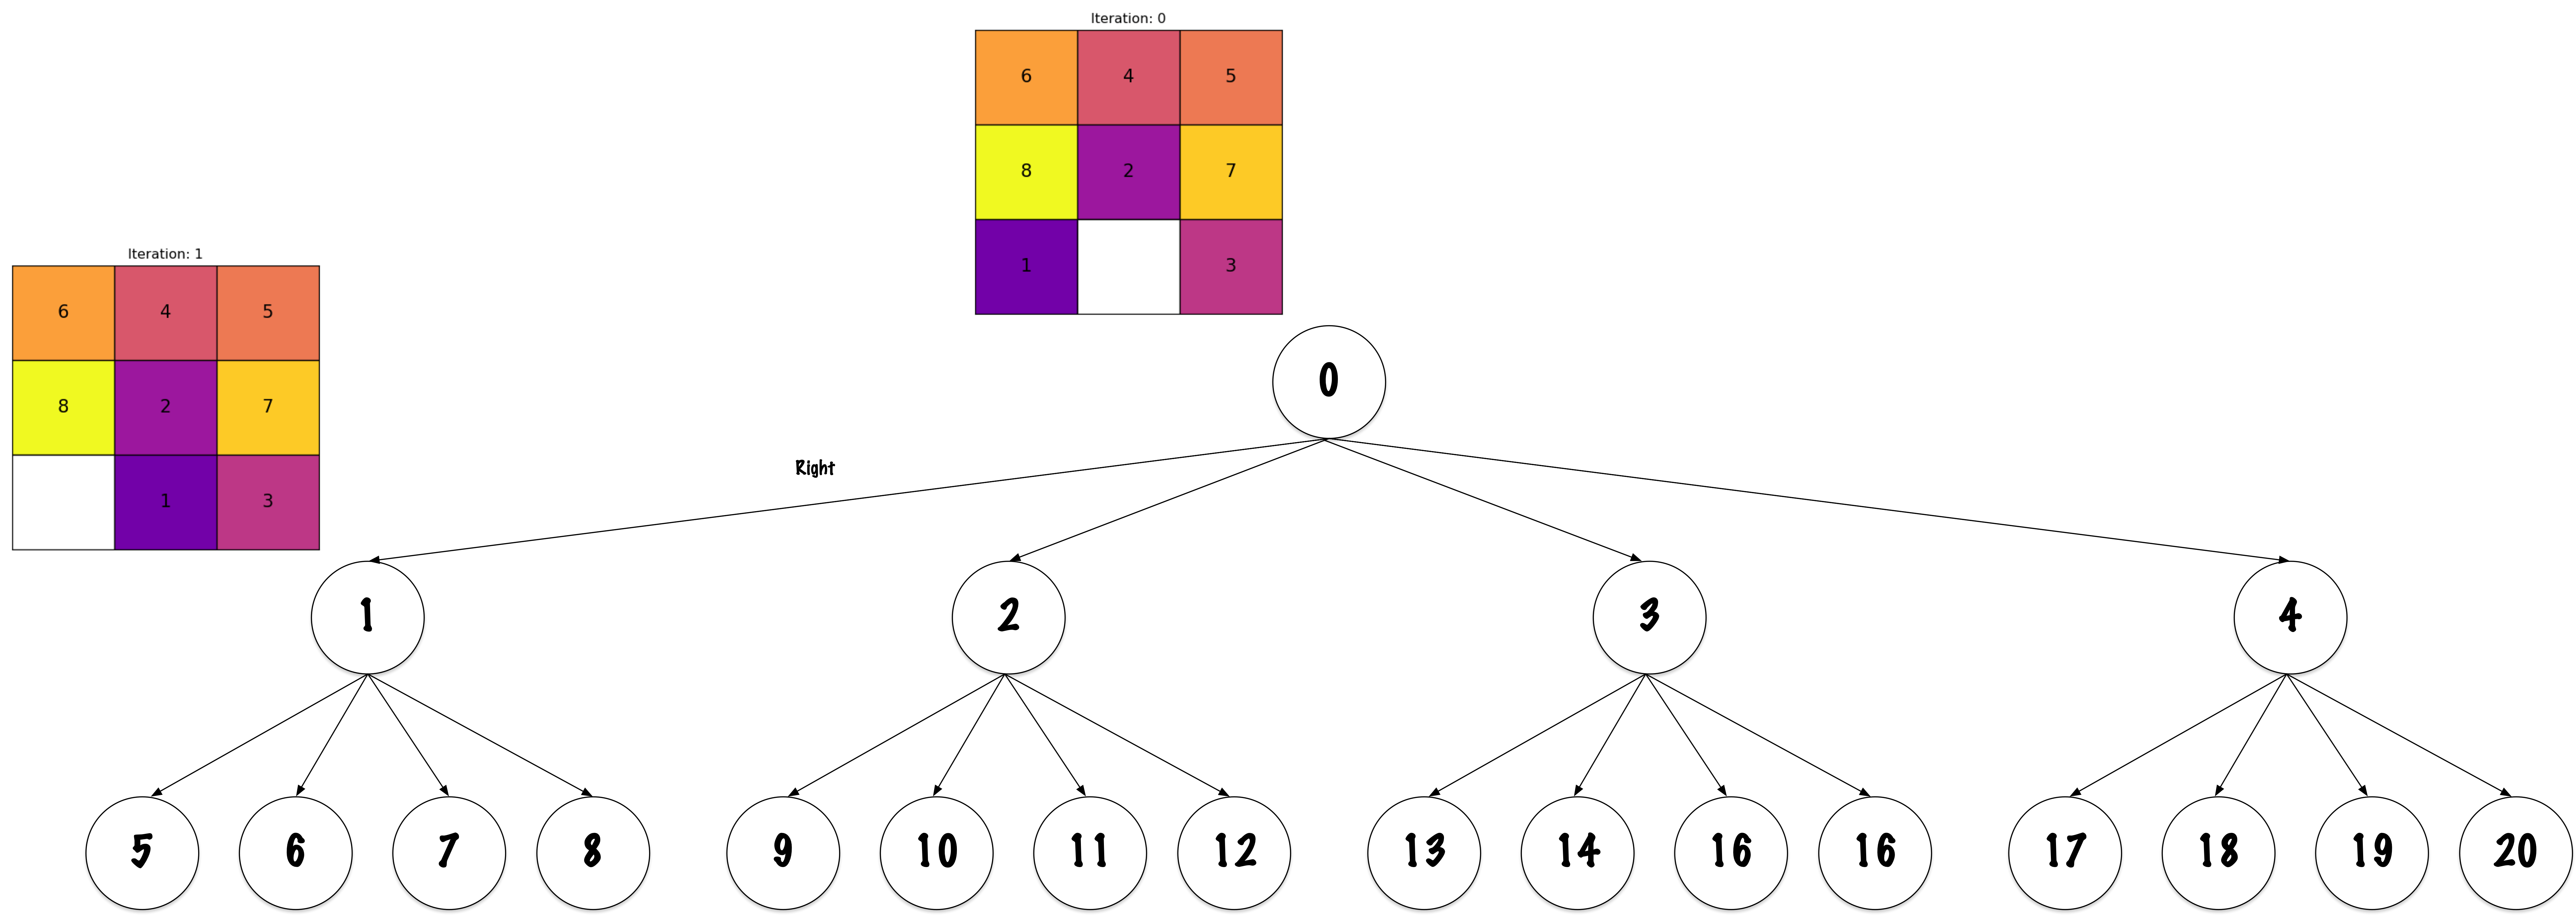

Un **arbre de recherche** est une *structure d’arbre conceptuelle* où
les **nœuds** représentent des *états* dans un **espace d’états**, et
les **arêtes** représentent les **actions** possibles, facilitant
l’exploration systématique pour trouver un **chemin** d’un **état
initial** à un **état objectif**.

Les algorithmes de recherche que nous examinons aujourd’hui construisent
un arbre de recherche, où chaque nœud représente un état au sein de
l’espace d’états et chaque arête représente une action.

Il est important de distinguer entre l’arbre de recherche et l’espace
d’états, qui peut être représenté comme un graphe. La structure de
l’arbre de recherche varie en fonction de l’algorithme utilisé pour
aborder le problème de recherche.

## Arbre de recherche



Un exemple d’**arbre de recherche** pour le **8-Puzzle**. La solution
ici est incomplète.

## Frontière



Tout état correspondant à un nœud dans l’arbre de recherche est
considéré comme **atteint**. Les nœuds de la **frontière** sont ceux qui
ont été **atteints** mais n’ont **pas encore été développés**.
Ci-dessus, il y a **10 nœuds développés** et **11 nœuds de frontière**,
ce qui donne un total de 21 nœuds qui ont été **atteints**.

## Frontière

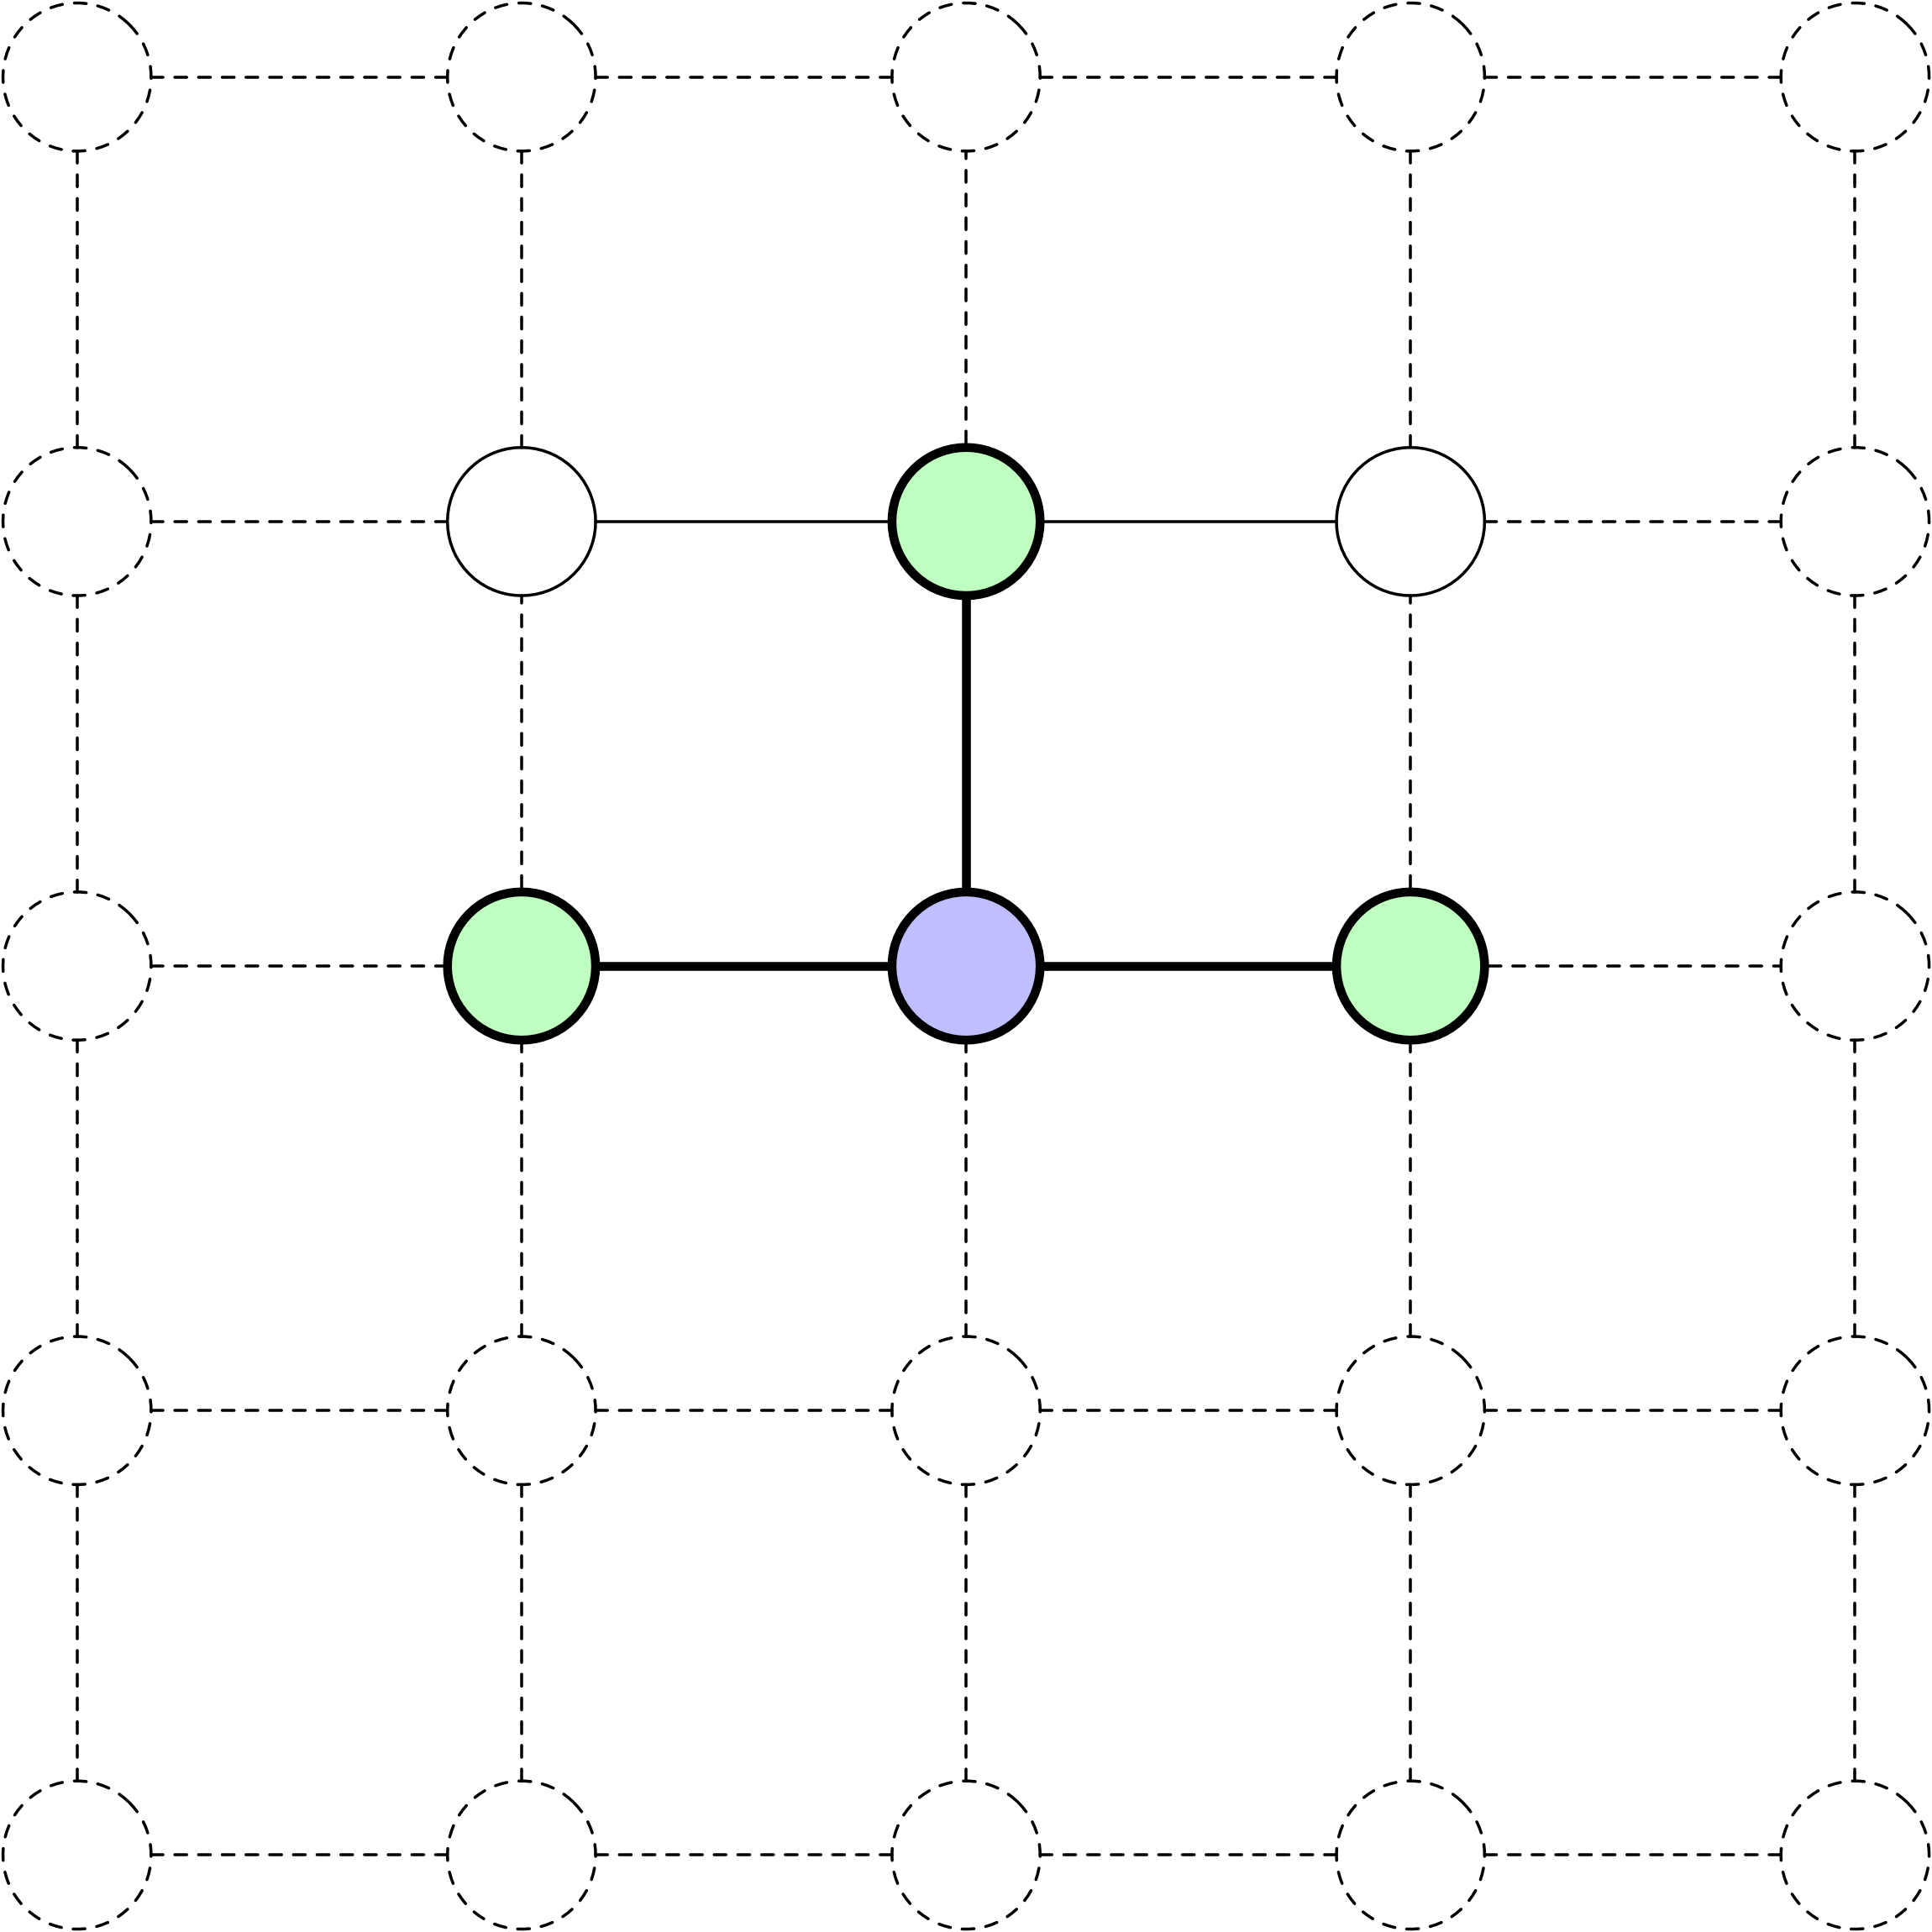

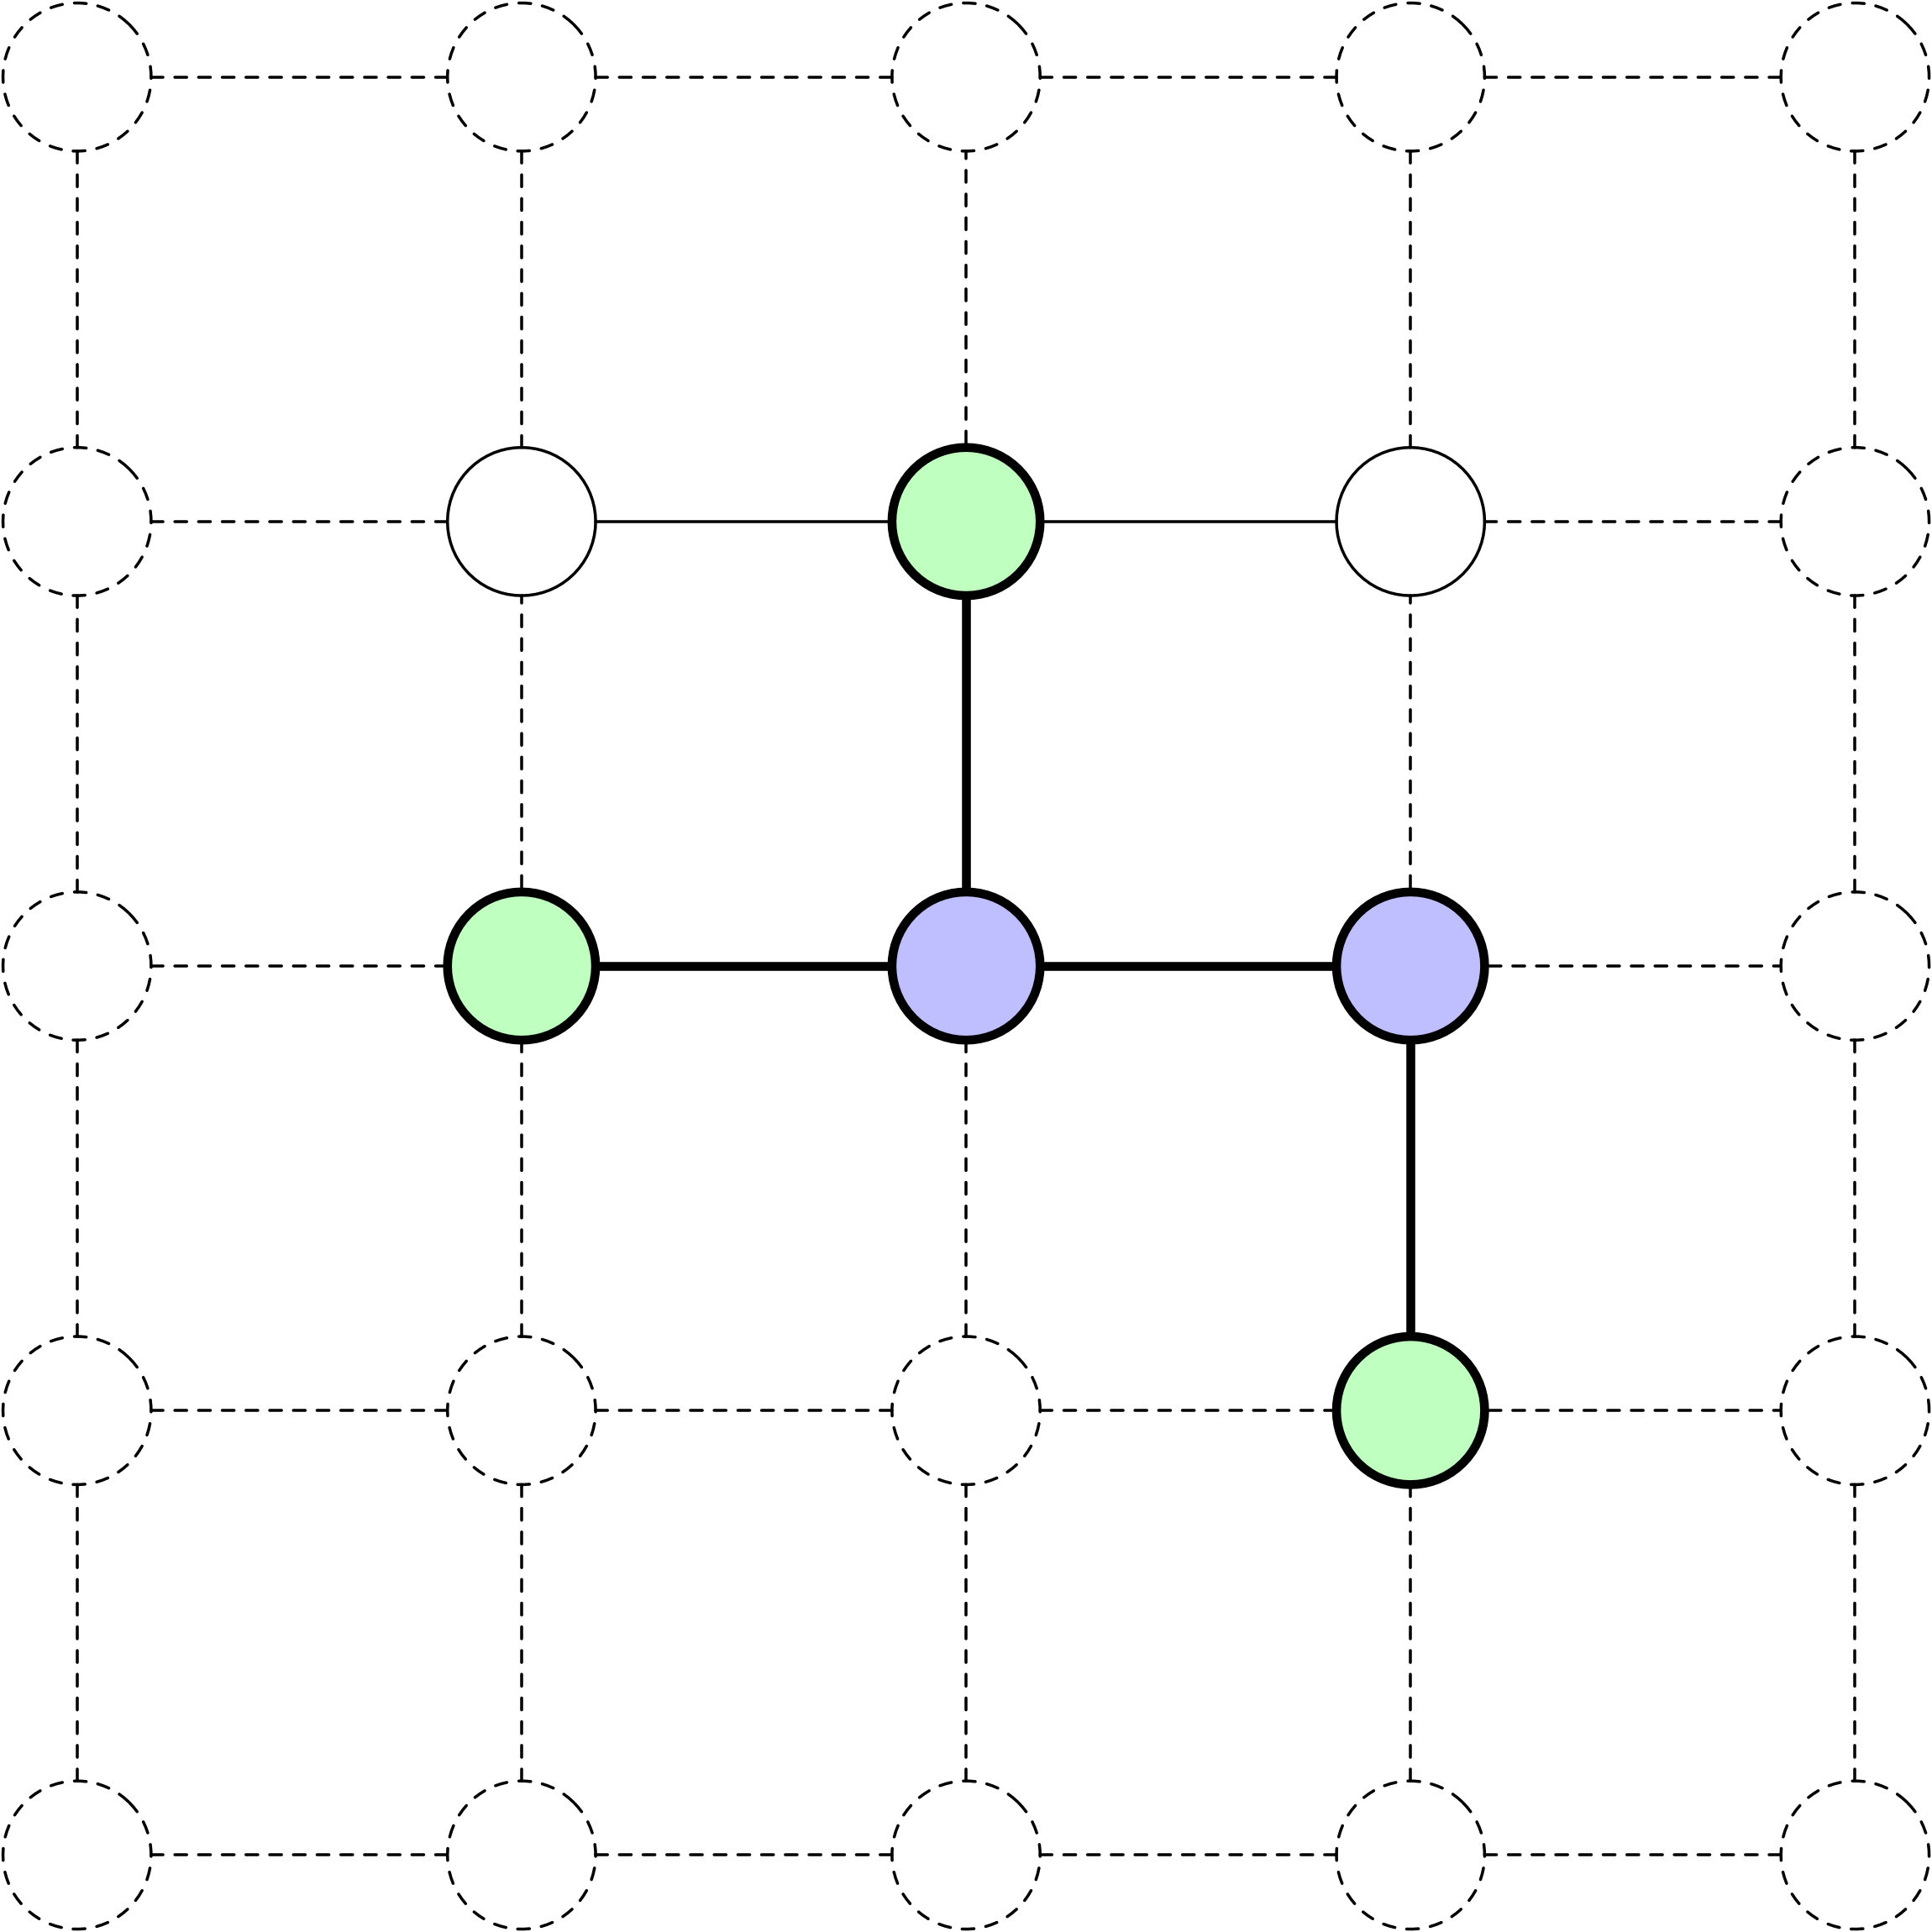

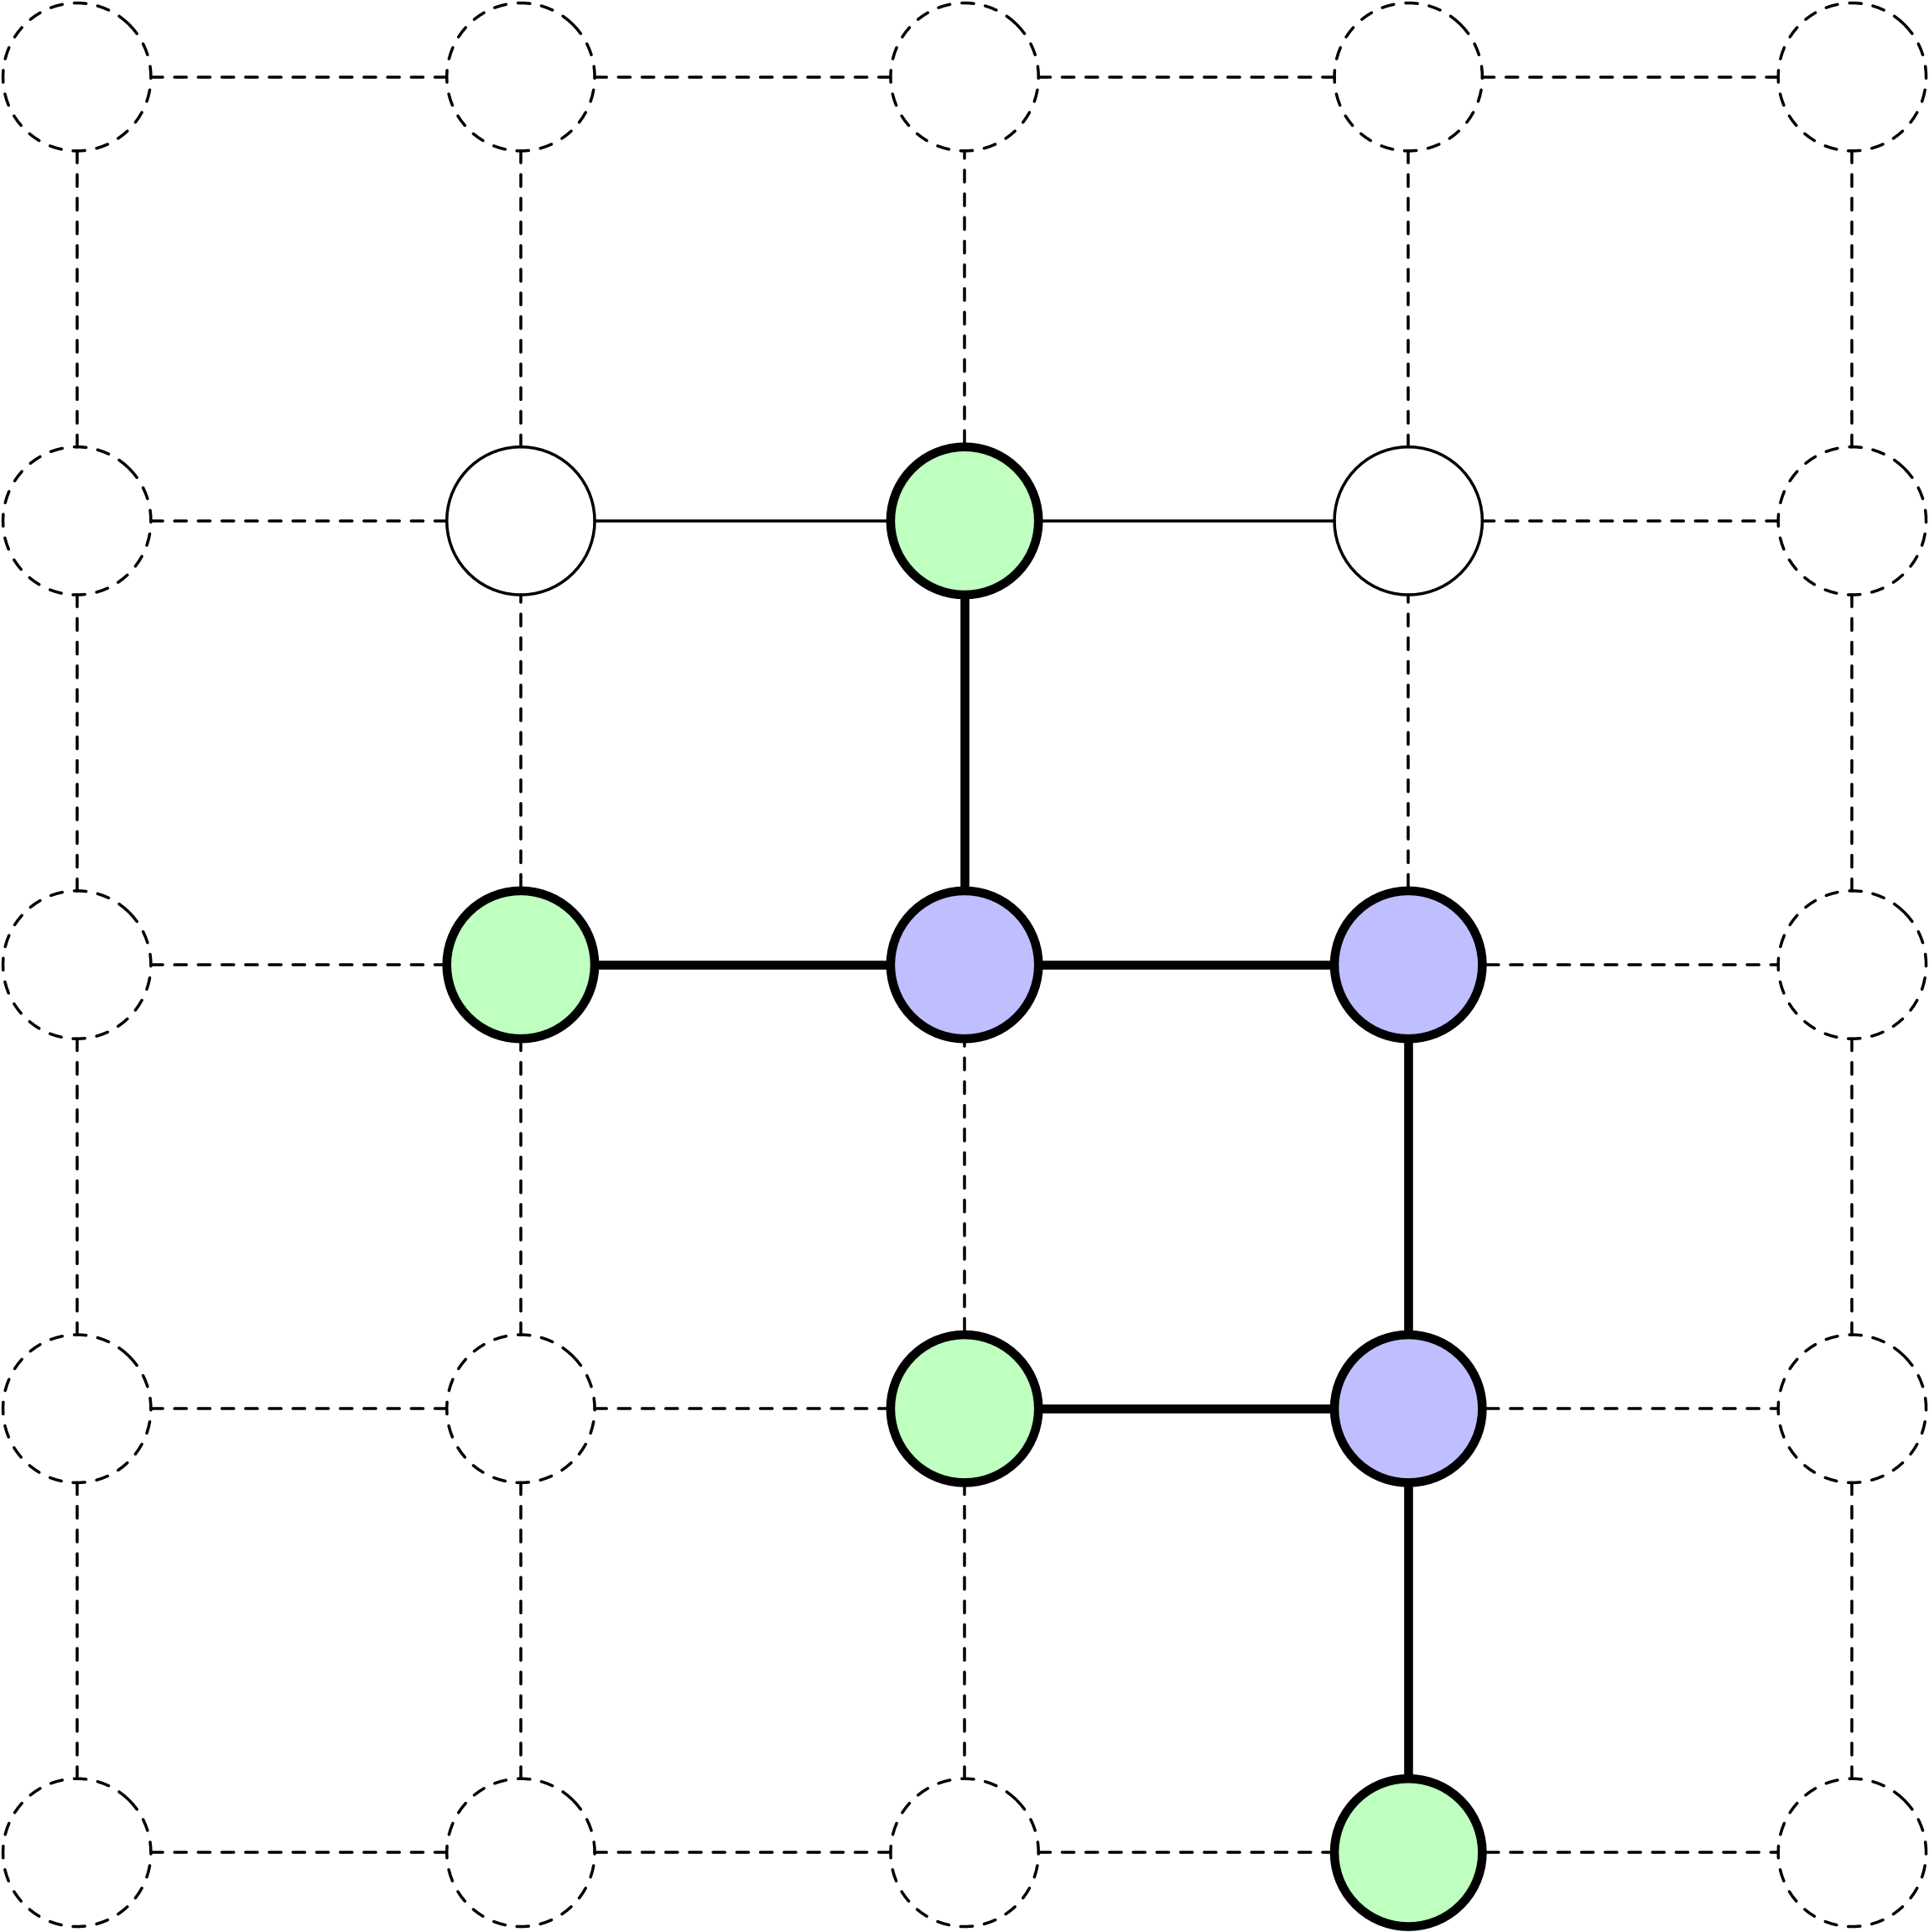

Dans le 8-Puzzle, quatre actions sont possibles : glisser à **gauche**,
à **droite**, vers le **haut** ou vers le **bas**. La recherche peut
être visualisée sur une grille : **nœuds violets** : états développés,
**nœuds verts** : états de la frontière (atteints mais non développés).

Les diagrammes correspondent à l’arbre de recherche présenté sur la page
précédente. Par exemple, l’état initial peut être développé en utilisant
trois actions : glisser à gauche, à droite et vers le haut. Le nœud (2,
3) ne peut être développé qu’en glissant vers le bas, tandis que le nœud
(3, 3) peut être développé en glissant à gauche et vers le bas.

## Frontière

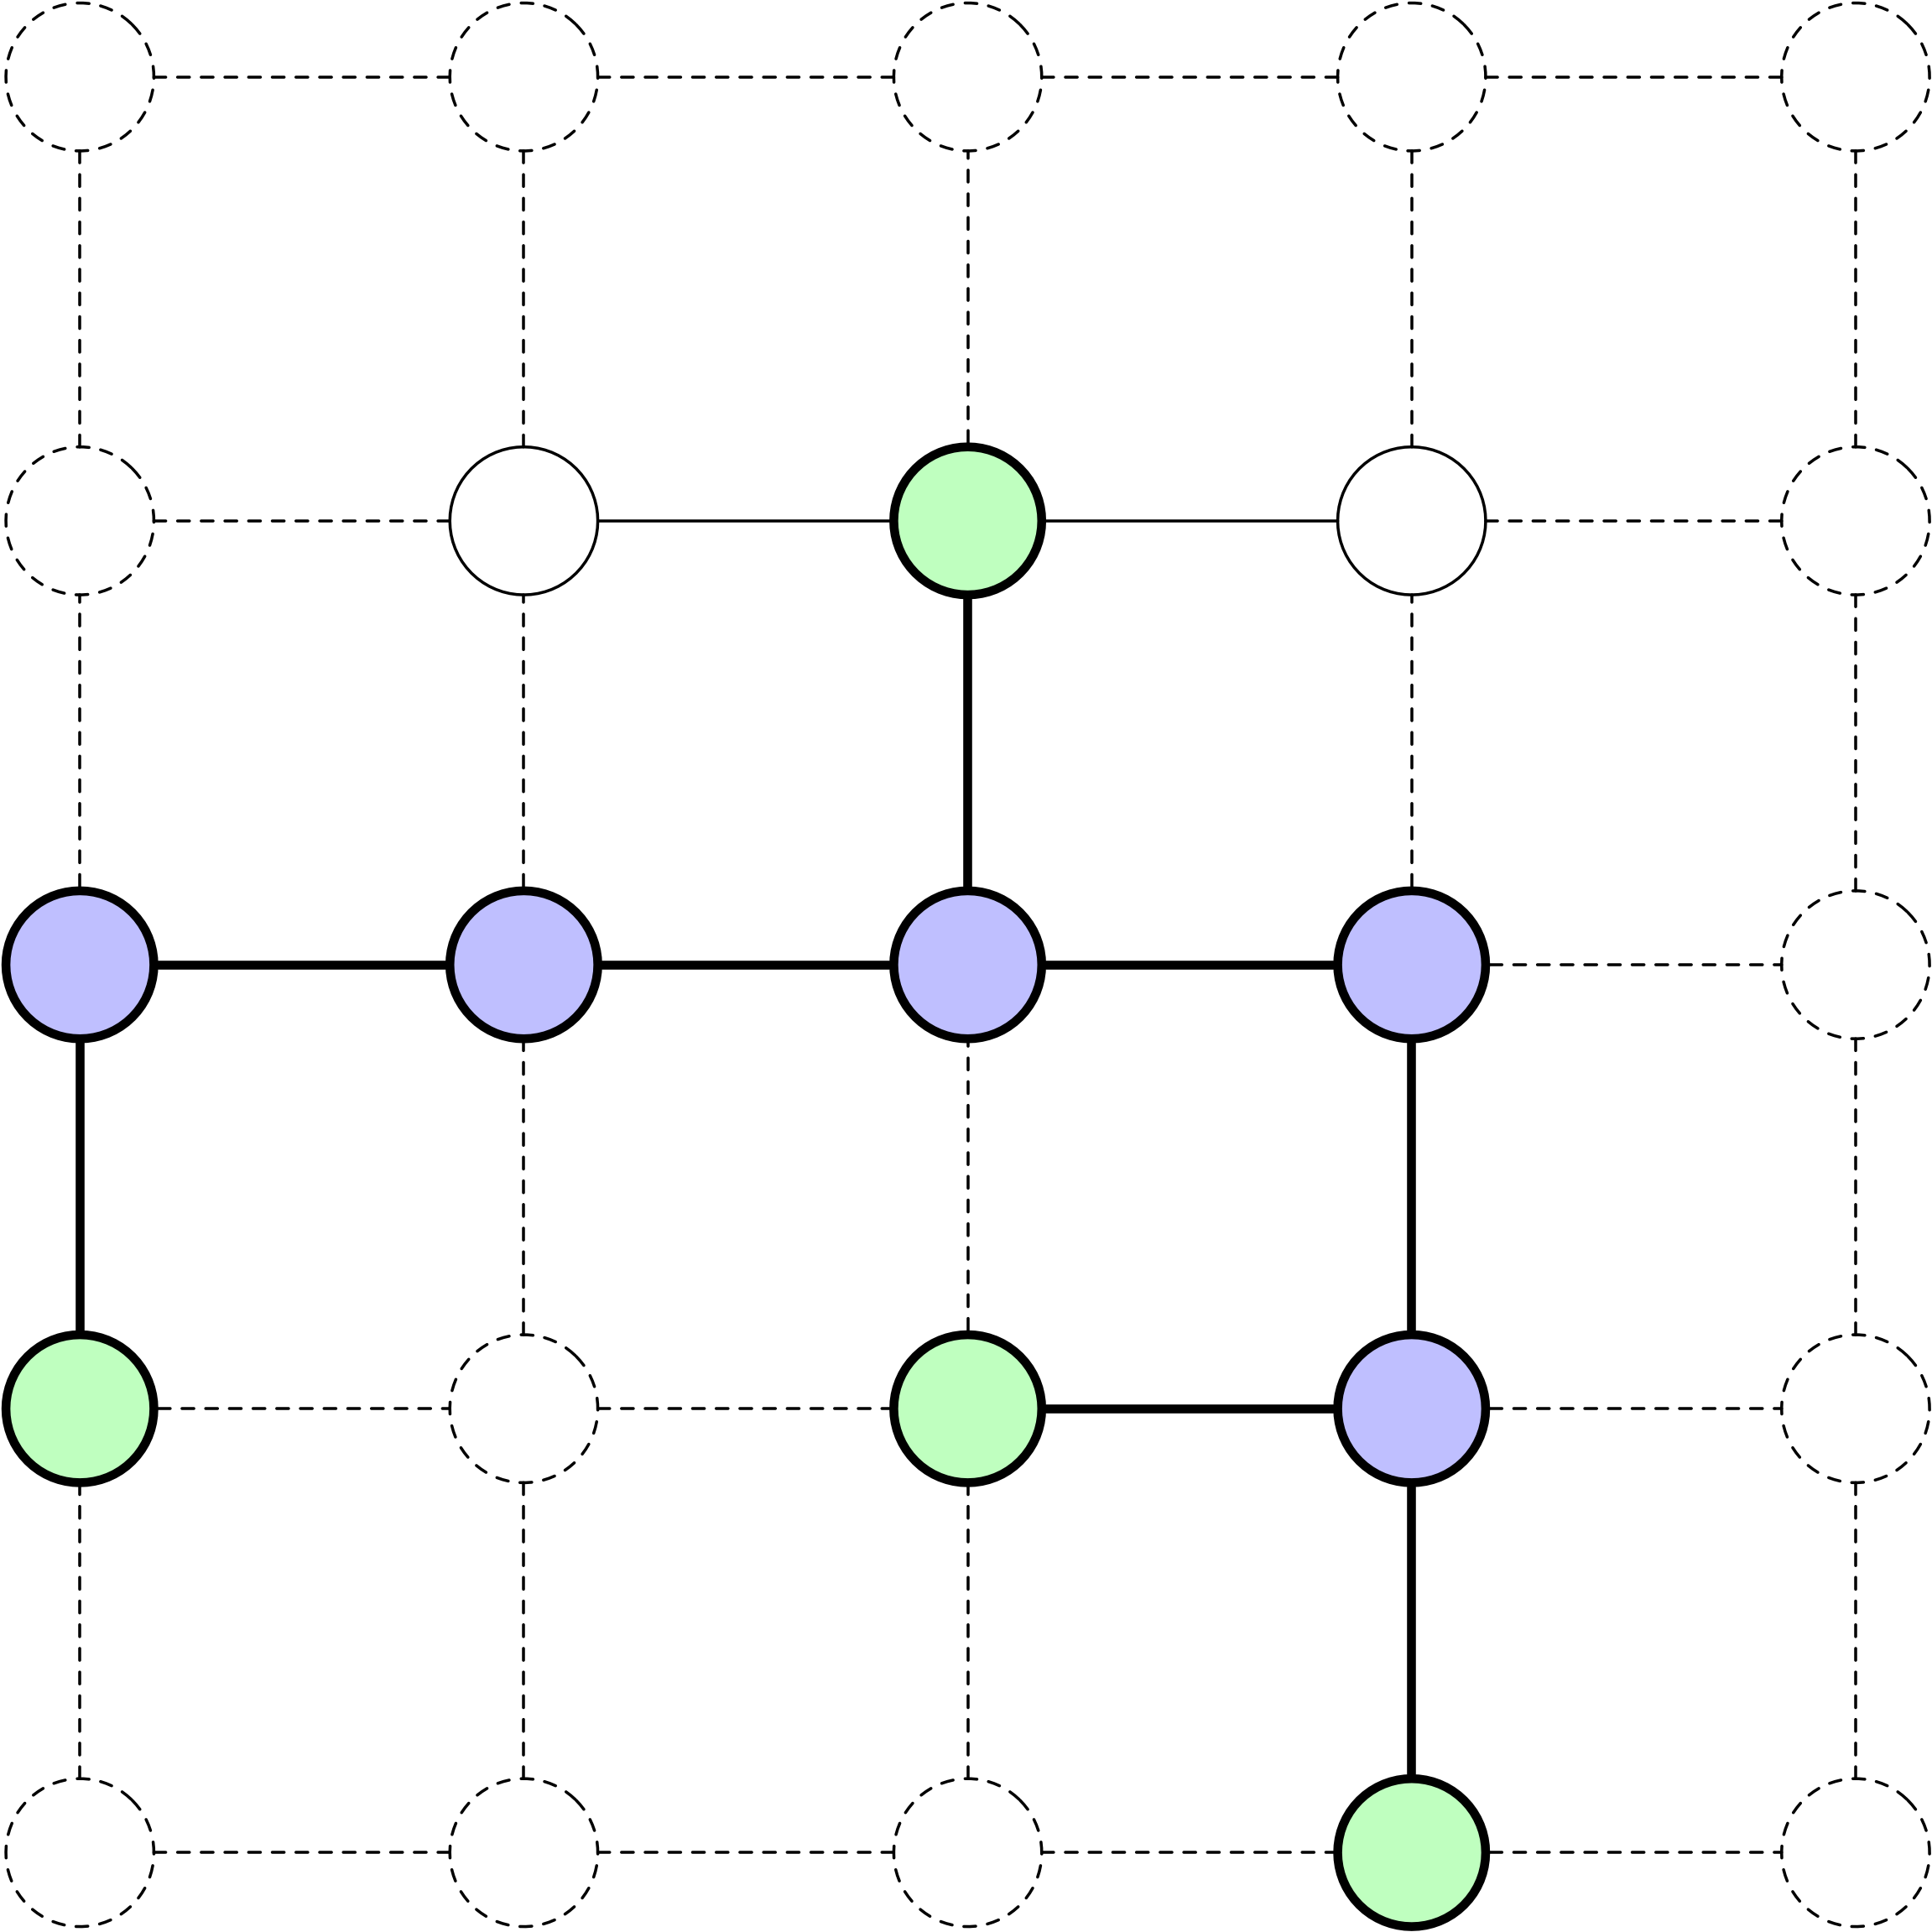

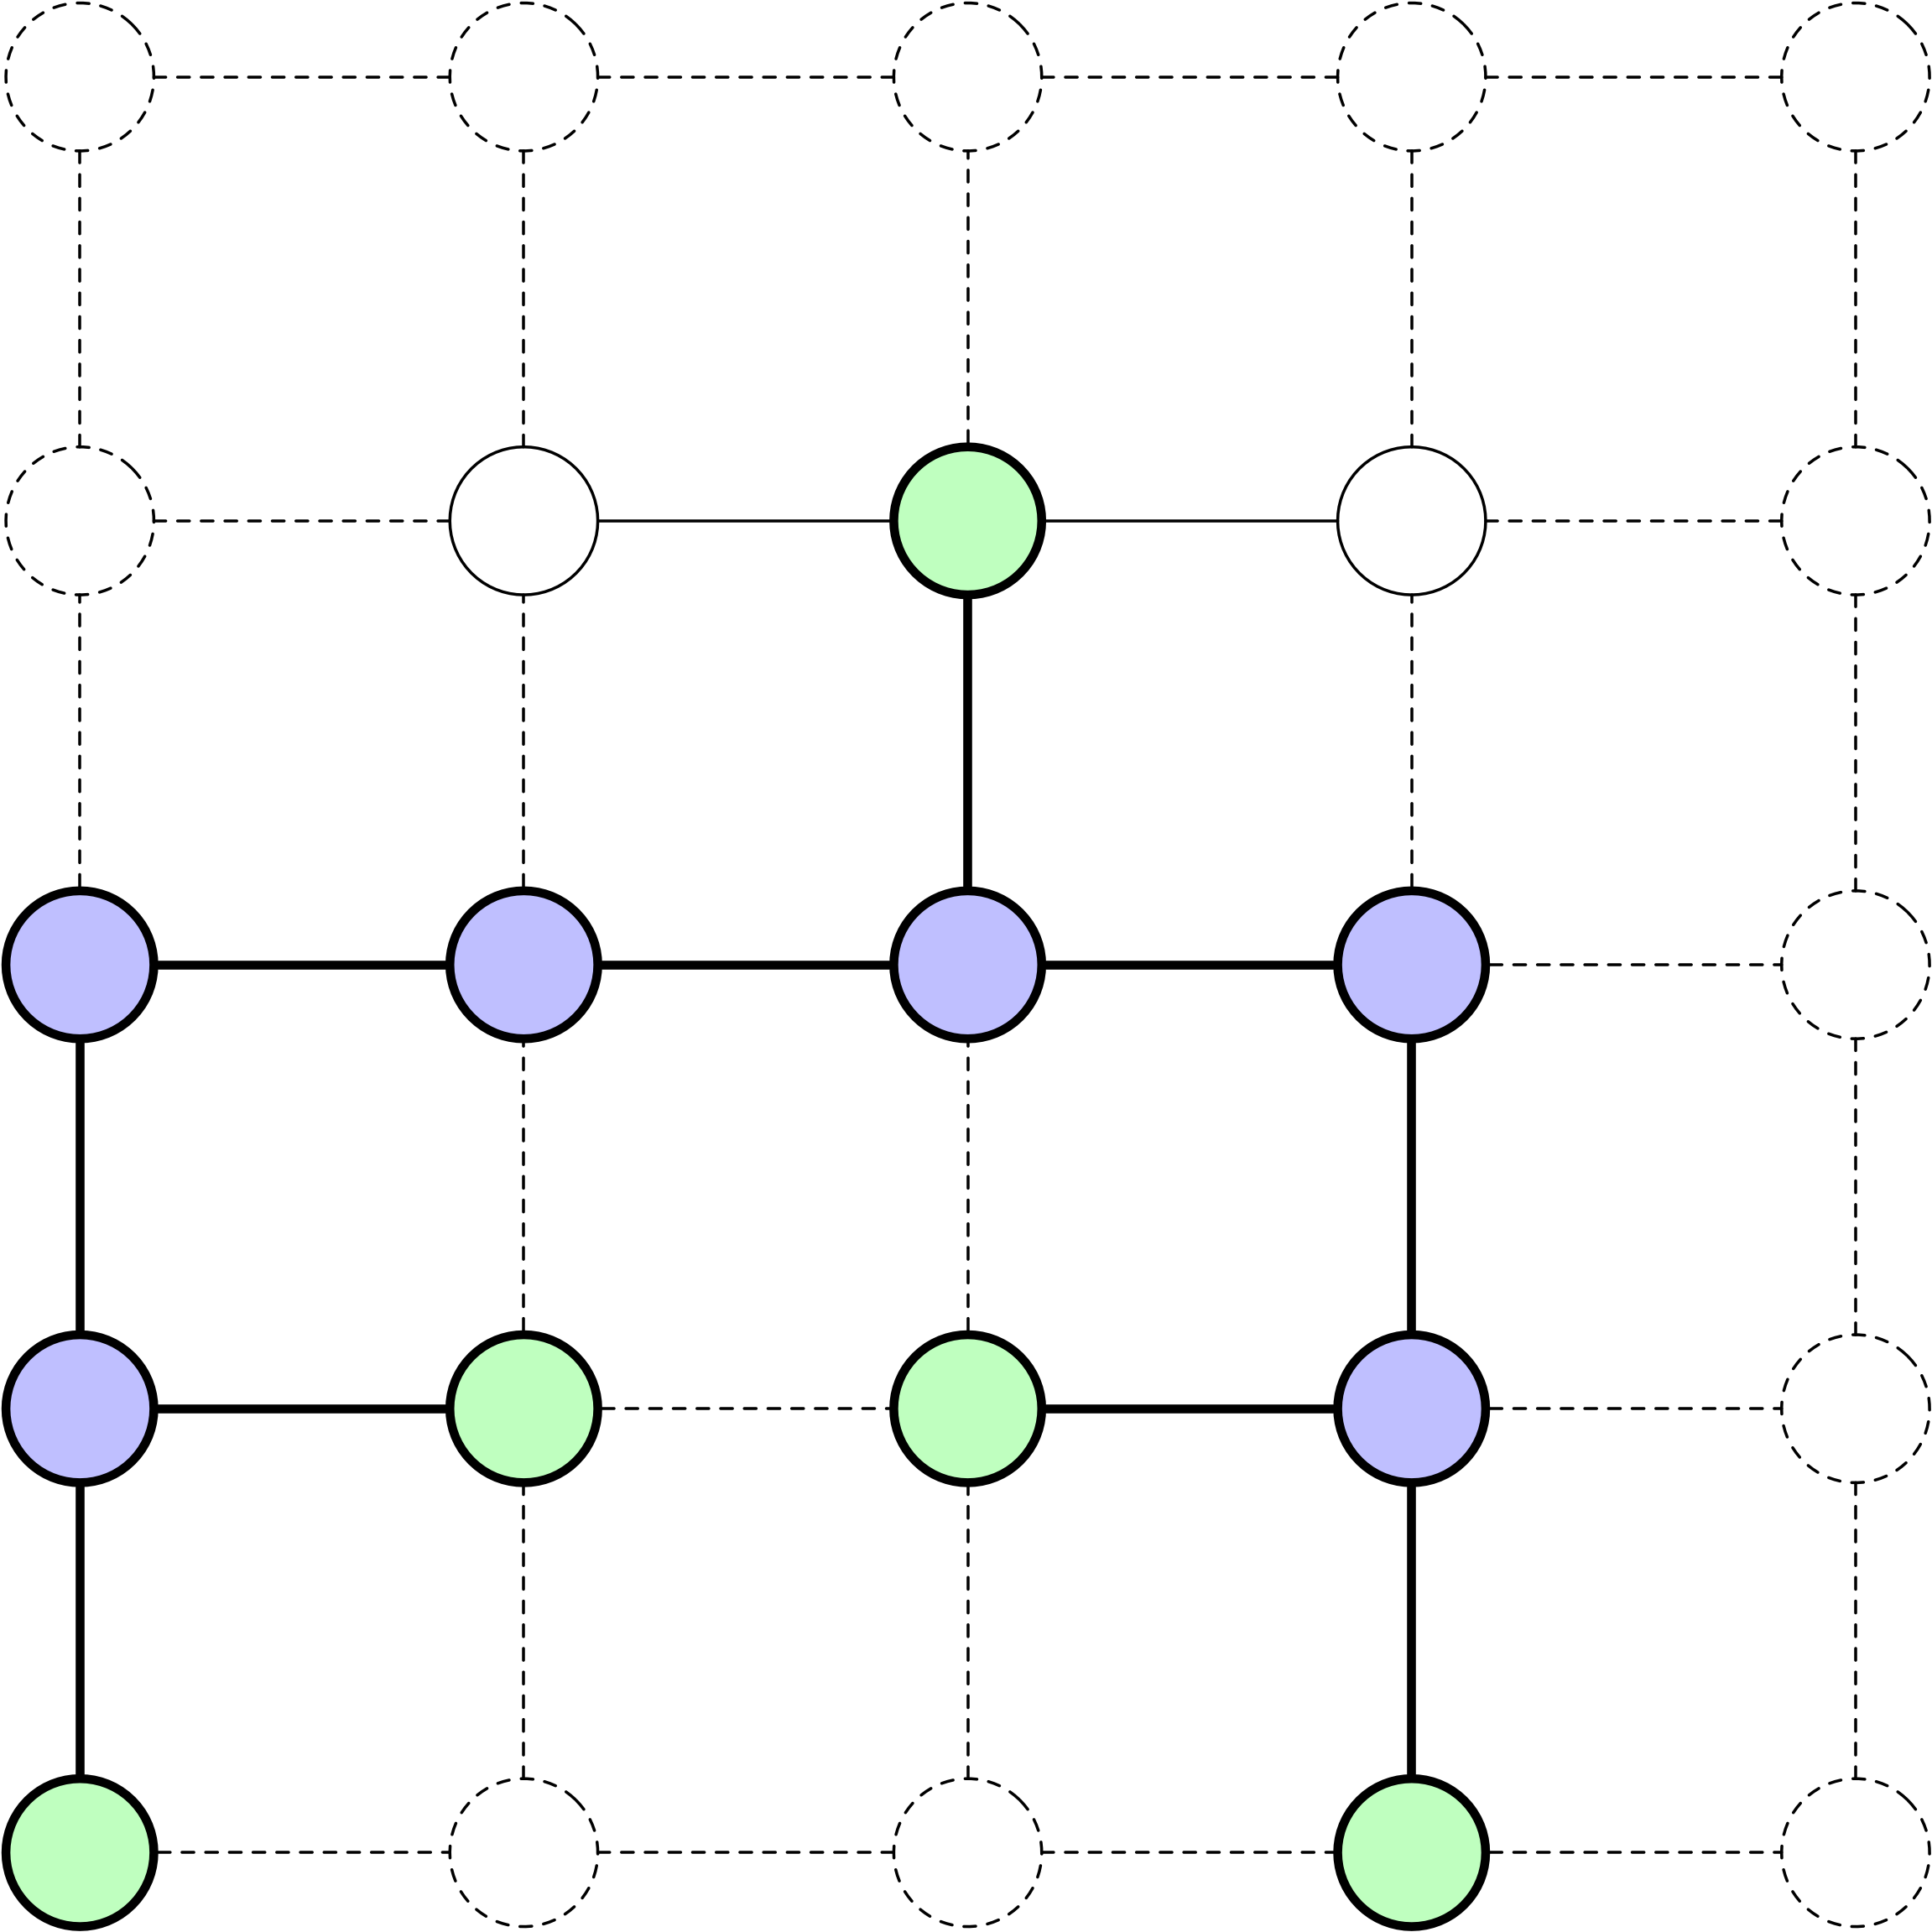

## `is_empty`

In [4]:
def is_empty(frontier):
    """Vérifie si la frontière est vide."""
    return len(frontier) == 0

Si la frontière devient vide (plus de nœuds à développer), le problème
n’a pas de solution.

Existe-t-il des plateaux de 8-Puzzle qui n’ont pas de solutions ?

La résolubilité du 8-Puzzle dépend du nombre d’**inversions** dans
l’état initial. Une inversion est une paire de tuiles où une tuile avec
un numéro plus élevé précède une tuile avec un numéro plus bas lorsque
le puzzle est vu comme une séquence (en excluant la tuile vide).

## `is_goal`

In [5]:
def is_goal(state, goal_state):
    """Détermine si un état donné correspond à l'état objectif."""
    return state == goal_state

Méthode auxiliaire.

## `expand`

In [6]:
def expand(state):
    """Génère les états successeurs en déplaçant la tuile vide dans toutes les directions possibles."""
    size = int(len(state) ** 0.5) # Déterminer la taille du puzzle (3 pour le 8-Puzzle, 4 pour le 15-Puzzle)
    idx = state.index(0) # Trouver l'index de la tuile vide représentée par 0
    x, y = idx % size, idx // size # Convertir l'index en coordonnées (x, y)
    neighbors = []

    # Définir les mouvements possibles : Gauche, Droite, Haut, Bas
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    for dx, dy in moves:
        nx, ny = x + dx, y + dy
        # Vérifier si la nouvelle position est dans les limites du puzzle
        if 0 <= nx < size and 0 <= ny < size:
            n_idx = ny * size + nx
            new_state = state.copy()
            # Échanger la tuile vide avec la tuile adjacente
            new_state[idx], new_state[n_idx] = new_state[n_idx], new_state[idx]
            neighbors.append(new_state)
    return neighbors

## `print_solution`

In [7]:
def print_solution(solution):
    """Affiche la séquence d'étapes de l'état initial à l'état objectif."""
    size = int(len(solution[0]) ** 0.5)
    for step, state in enumerate(solution):
        print(f"Étape {step} :")
        for i in range(size):
            row = state[i*size:(i+1)*size]
            print(' '.join(str(n) if n != 0 else ' ' for n in row))
        print()

## Recherche en largeur

In [8]:
from collections import deque

La **recherche en largeur (BFS)** utilise une **file d’attente** pour
gérer les nœuds de la frontière, également connus sous le nom de liste
ouverte.

## Recherche en largeur

In [9]:
def bfs(initial_state, goal_state):
    frontier = deque() # Initialiser la file d'attente pour BFS
    frontier.append((initial_state, [])) # Chaque élément est un tuple : (état, chemin)

    explored = set()
    explored.add(tuple(initial_state))

    iterations = 0 # utilisé simplement pour comparer les algorithmes

    while not is_empty(frontier):
        current_state, path = frontier.popleft()

        if is_goal(current_state, goal_state):
            print(f"Nombre d'itérations : {iterations}")
            return path + [current_state] # Retourner le chemin réussi

        iterations = iterations + 1

        for neighbor in expand(current_state):
            neighbor_tuple = tuple(neighbor)
            if neighbor_tuple not in explored:
                explored.add(neighbor_tuple)
                frontier.append((neighbor, path + [current_state]))

    return None # Aucune solution trouvée

L’utilisation de `tuple` rend les états immuables et “hachables”,
permettant leur stockage dans un ensemble.

## Recherche en profondeur

In [10]:
def dfs(initial_state, goal_state):
    frontier = [(initial_state, [])] # Chaque élément est un tuple : (état, chemin)

    explored = set()
    explored.add(tuple(initial_state))

    iterations = 0

    while not is_empty(frontier):
        current_state, path = frontier.pop()

        if is_goal(current_state, goal_state):
            print(f"Nombre d'itérations : {iterations}")
            return path + [current_state] # Retourner le chemin réussi

        iterations = iterations + 1

        for neighbor in expand(current_state):
            neighbor_tuple = tuple(neighbor)
            if neighbor_tuple not in explored:
                explored.add(neighbor_tuple)
                frontier.append((neighbor, path + [current_state]))

    return None # Aucune solution trouvée

## Remarques

-   La **recherche en largeur (BFS)** identifie la solution optimale, 25
    mouvements, en 145 605 itérations.

-   La **recherche en profondeur (DFS)** découvre une solution
    impliquant 1 157 mouvements en 1 187 itérations.

Comment découvrir des solutions **plus efficacement** ?

La **recherche en profondeur (DFS)** produira-t-elle toujours des
solutions sous-optimales ?

Non, si la solution optimale se trouve le long du chemin parcouru par la
recherche en profondeur (DFS) dans l’arbre de recherche, alors DFS
identifiera effectivement la solution optimale.

Est-il possible que DFS découvre des solutions supérieures à la solution
optimale ?

Certainement pas ; de telles solutions seraient soit invalides
(impliquant des mouvements impossibles), soit indiqueraient une erreur
dans votre estimation.

Cela signifie-t-il que la recherche en profondeur (DFS) n’a pas
d’applications pratiques ?

Quand est-il approprié d’utiliser DFS ?

La recherche en largeur (BFS) étend sa frontière systématiquement dans
toutes les directions, ce qui entraîne une croissance rapide des besoins
en mémoire.

En revanche, l’utilisation de la mémoire de DFS est limitée par le
nombre de mouvements nécessaires pour atteindre ses points de retour en
arrière ou par la longueur du chemin de la première solution trouvée.
Dans tous les scénarios, DFS continue d’étendre la frontière dans une
direction.

Dans certaines applications où toutes les solutions possibles doivent
être explorées, tout l’espace de recherche doit être parcouru. Utiliser
BFS dans ces cas serait prohibitif en termes de mémoire. Cependant, DFS
peut explorer l’ensemble de l’espace avec une utilisation minimale de la
mémoire.

Le langage de programmation Prolog inclut un algorithme de retour en
arrière intégré qui énumère toutes les solutions possibles. Le retour en
arrière est une variante de DFS efficace en mémoire.

La recherche limitée en profondeur et la recherche en approfondissement
itératif seraient des algorithmes de recherche non informée alternatifs.

Trouver des solutions plus efficacement nécessite une connaissance du
domaine.

# Recherche informée

## Recherche heuristique

Les algorithmes de recherche informée utilisent des **connaissances
spécifiques au domaine** concernant l’emplacement de l’état objectif.

## Recherche heuristique

Soit $f(n)$ une **fonction heuristique** qui estime le **coût du chemin
de moindre coût** de l’état ou du nœud actuel $n$ jusqu’à l’objectif.

Cette approche est appelée **recherche du meilleur d’abord**
(*best-first search*).

## Recherche heuristique

Dans les **problèmes de recherche de route**, on pourrait utiliser la
distance en ligne droite du nœud actuel à la destination comme
heuristique. Bien qu’un chemin réel puisse ne pas exister le long de
cette ligne droite, l’algorithme donnera la priorité à l’expansion du
nœud le plus proche de la destination (objectif) en se basant sur cette
mesure en ligne droite.

## Implémentation

-   Comment peut-on modifier les algorithmes existants de **recherche en
    largeur** et de **recherche en profondeur** pour implémenter la
    **recherche du meilleur d’abord** ?

    -   Cela peut être réalisé en utilisant une **file de priorité**,
        qui est triée selon les valeurs de la **fonction heuristique**
        $f(n)$.

. . .

In [11]:
import heapq

## Observation

La **recherche en largeur** peut être interprétée comme une forme de
recherche du meilleur d’abord, où la fonction heuristique $f(n)$ est
définie comme la **profondeur du nœud dans l’arbre de recherche**,
correspondant à la longueur du chemin.

Cette solution est-elle viable ? La réponse est nuancée. Elle est utile
pour examiner les propriétés de l’algorithme, mais l’utilisation d’une
file d’attente offrira probablement une implémentation plus efficace.

Comment pourrait-on implémenter la recherche en profondeur comme une
forme de recherche du meilleur d’abord?

## $A^\star$

$A^\star$ (a-star) est la **recherche informée la plus courante**.

$$
    f(n) = g(n) + h(n)
$$

où

-   $g(n)$ est le coût du chemin depuis l’*état initial* jusqu’à $n$.
-   $h(n)$ est une **estimation** du coût du plus court chemin de $n$ à
    l’*état final*.

Hart, Nilsson, et Raphael (1968)

Il est évident que $g(n)$ est une valeur connue et non une estimation.
Par conséquent, la précision de $f(n)$ s’améliore au fur et à mesure de
l’exécution.

## Admissibilité

Une heuristique est **admissible** si *elle ne surestime jamais le coût
réel pour atteindre l’objectif à partir de n’importe quel nœud dans
l’espace de recherche*.

Cela garantit que l’algorithme $A^\star$ trouve une solution optimale,
puisque le coût estimé est toujours une borne inférieure du coût réel.

## Admissibilité

Formellement, une heuristique $h(n)$ est admissible si : $$
h(n) \leq h^*(n)
$$ où :

-   $h(n)$ est l’estimation heuristique du coût depuis le nœud $n$
    jusqu’à l’objectif.
-   $h^*(n)$ est le coût réel du chemin optimal depuis le nœud $n$
    jusqu’à l’objectif.

Que se passerait-il si une heuristique surestimait le coût du plus court
chemin de $n$ à l’objectif ?

## Optimalité de coût

L’**optimalité de coût** se réfère à la capacité d’un algorithme à
trouver la solution de moindre coût parmi toutes les solutions
possibles. Dans le contexte des algorithmes de recherche comme
$A^\star$, l’optimalité de coût signifie que l’algorithme identifiera le
chemin avec le coût total le plus bas depuis le départ jusqu’à
l’objectif, à condition qu’une heuristique admissible soit utilisée.

## Preuve d’optimalité

**Théorème :** Si $h(n)$ est une heuristique admissible, alors $A^\star$
utilisant $h(n)$ trouvera toujours une solution optimale si elle existe.

**Preuve :**

1.  **Hypothèse par contradiction :** Supposons que $A^\star$ retourne
    une solution sous-optimale avec un coût $C > C^\star$, où $C^\star$
    est le coût de la solution optimale.

2.  **État de la frontière :** Au moment où $A^\star$ trouve et retourne
    la solution sous-optimale, il ne doit y avoir aucun nœud inexploré
    $n$ dans la frontière (liste ouverte) tel que $f(n) \leq C^\star$.
    S’il existait un tel nœud, $A^\star$ l’aurait sélectionné pour
    l’expansion avant le nœud menant à la solution sous-optimale en
    raison de sa valeur $f(n)$ inférieure.

3.  **Existence de nœuds sur le chemin optimal :** Cependant, le long du
    chemin optimal vers l’objectif, il doit y avoir des nœuds $n$ tels
    que $f(n) = g(n) + h(n) \leq C^\star$, car :

    -   $g(n)$ est le coût du début à $n$ le long du chemin optimal,
        donc $g(n) \leq C^\star$.
    -   $h(n) \leq h^*(n)$ parce que $h(n)$ est admissible.
    -   $h^*(n)$ est le coût réel de $n$ à l’objectif le long du chemin
        optimal, donc $g(n) + h^*(n) = C^\star$.
    -   Par conséquent,
        $f(n) = g(n) + h(n) \leq g(n) + h^*(n) = C^\star$.

4.  **Contradiction :** Cela signifie qu’il y a des nœuds dans la
    frontière avec $f(n) \leq C^\star$ qui n’ont pas encore été
    explorés, ce qui contredit l’hypothèse qu’aucun de ces nœuds
    n’existe au moment où la solution sous-optimale est retournée.

5.  **Conclusion :** Par conséquent, $A^\star$ ne peut pas retourner une
    solution sous-optimale lorsqu’il utilise une heuristique admissible.
    Il doit trouver la solution optimale avec un coût $C^\star$.
    C.Q.F.D.

## 8-Puzzle

Pouvez-vous penser à une fonction heuristique pour le casse-tête de 8
tuiles ?

## Distance des tuiles mal placées

In [12]:
def misplaced_tiles_distance(state, goal_state):
    # Comptez le nombre de tuiles mal placées
    misplaced_tiles = sum(1 for s, g in zip(state, goal_state) if s != g and s != 0)
    return misplaced_tiles

Est-ce que cette heuristique est admissible?

## 8-Puzzle

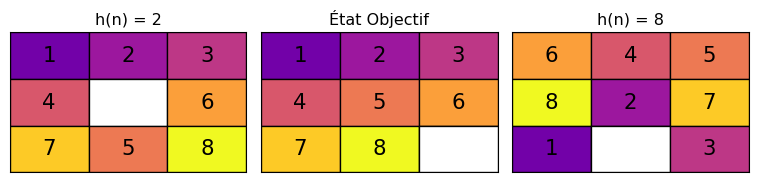

## Recherche du meilleur d’abord

In [14]:
def best_first_search(initial_state, goal_state):

    frontier = []  # Initialisez la file de priorité
    initial_h = misplaced_tiles_distance(initial_state, goal_state)

    # Ajoutez l'état initial avec sa valeur heuristique dans la file
    heapq.heappush(frontier, (initial_h, 0, initial_state, []))  # (f(n), g(n), état, chemin)

    explored = set()
    iterations = 0

    while not is_empty(frontier):
        f, g, current_state, path = heapq.heappop(frontier)

        if is_goal(current_state, goal_state):
            print(f"Nombre d'itérations : {iterations}")
            return path + [current_state]  # Retournez le chemin réussi

        iterations += 1
        explored.add(tuple(current_state))

        for neighbor in expand(current_state):
            if tuple(neighbor) not in explored:
                new_g = g + 1  # Incrémentez le coût du chemin
                h = misplaced_tiles_distance(neighbor, goal_state)
                new_f = new_g + h  # Calculez le nouveau coût total
                # Ajoutez l'état voisin dans la file de priorité
                heapq.heappush(frontier, (new_f, new_g, neighbor, path + [current_state]))
                explored.add(tuple(neighbor))  # Marquez le voisin comme exploré

    return None  # Aucune solution trouvée

## Cas simple

Nombre d'itérations : 2

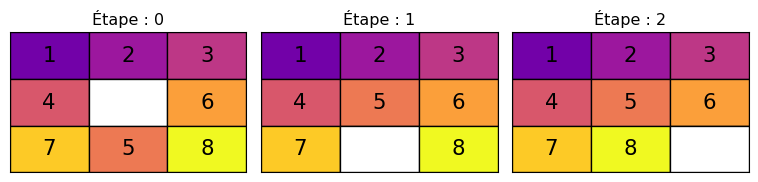

In [16]:
initial_state_8 = [1, 2, 3,
                   4, 0, 6,
                   7, 5, 8]
goal_state_8 = [1, 2, 3,
                4, 5, 6,
                7, 8, 0]

best_first_search(initial_state_8, goal_state_8)

Nombre d'itérations : 2

[[1, 2, 3, 4, 0, 6, 7, 5, 8],
 [1, 2, 3, 4, 5, 6, 7, 0, 8],
 [1, 2, 3, 4, 5, 6, 7, 8, 0]]

## Cas difficile

In [17]:
initial_state_8 = [6, 4, 5,
                   8, 2, 7,
                   1, 0, 3]
goal_state_8 = [1, 2, 3,
                4, 5, 6,
                7, 8, 0]

print("Résolution du casse-tête de 8 tuiles avec best_first_search...")

solution_8_bfs = best_first_search(initial_state_8, goal_state_8)

if solution_8_bfs:
    print(f"Solution trouvée par best_first_search en {len(solution_8_bfs) - 1} mouvements :")
    print_solution(solution_8_bfs)
else:
    print("Aucune solution trouvée pour le casse-tête de 8 tuiles avec best_first_search.")

Résolution du casse-tête de 8 tuiles avec best_first_search...
Nombre d'itérations : 29005
Solution trouvée par best_first_search en 25 mouvements :
Étape 0 :
6 4 5
8 2 7
1   3

Étape 1 :
6 4 5
8 2 7
  1 3

Étape 2 :
6 4 5
  2 7
8 1 3

Étape 3 :
6 4 5
2   7
8 1 3

Étape 4 :
6   5
2 4 7
8 1 3

Étape 5 :
  6 5
2 4 7
8 1 3

Étape 6 :
2 6 5
  4 7
8 1 3

Étape 7 :
2 6 5
4   7
8 1 3

Étape 8 :
2 6 5
4 1 7
8   3

Étape 9 :
2 6 5
4 1 7
  8 3

Étape 10 :
2 6 5
  1 7
4 8 3

Étape 11 :
2 6 5
1   7
4 8 3

Étape 12 :
2 6 5
1 7  
4 8 3

Étape 13 :
2 6 5
1 7 3
4 8  

Étape 14 :
2 6 5
1 7 3
4   8

Étape 15 :
2 6 5
1   3
4 7 8

Étape 16 :
2   5
1 6 3
4 7 8

Étape 17 :
2 5  
1 6 3
4 7 8

Étape 18 :
2 5 3
1 6  
4 7 8

Étape 19 :
2 5 3
1   6
4 7 8

Étape 20 :
2   3
1 5 6
4 7 8

Étape 21 :
  2 3
1 5 6
4 7 8

Étape 22 :
1 2 3
  5 6
4 7 8

Étape 23 :
1 2 3
4 5 6
  7 8

Étape 24 :
1 2 3
4 5 6
7   8

Étape 25 :
1 2 3
4 5 6
7 8  


## 8-Puzzle

In [18]:
def manhattan_distance(state, goal_state):
    distance = 0
    size = int(len(state) ** 0.5)
    for num in range(1, len(state)):
        idx1 = state.index(num)
        idx2 = goal_state.index(num)
        x1, y1 = idx1 % size, idx1 // size
        x2, y2 = idx2 % size, idx2 // size
        distance += abs(x1 - x2) + abs(y1 - y2)
    return distance

Calcule l’heuristique de **distance de Manhattan** pour un état donné.
Est-ce que cette heuristique est **admissible**?

## 8-Puzzle

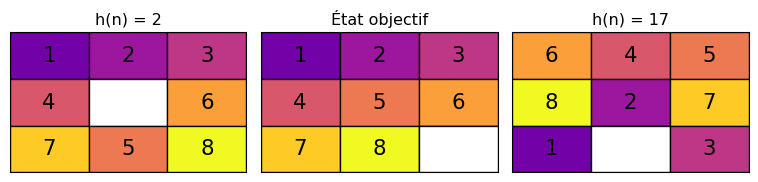

## 8-Puzzle

-   Comparer les heuristiques **Manhattan** et **Tuiles Mal Placées**.
-   Laquelle est la plus efficace ?
-   Différences significatives de temps d’exécution ?

## 8-Puzzle

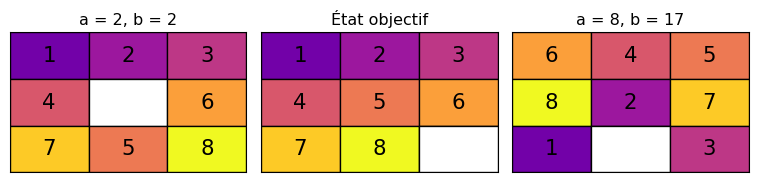

où

-   **a** = distance des tuiles mal placées
-   **b** = distance de Manathan

## 8-Puzzle

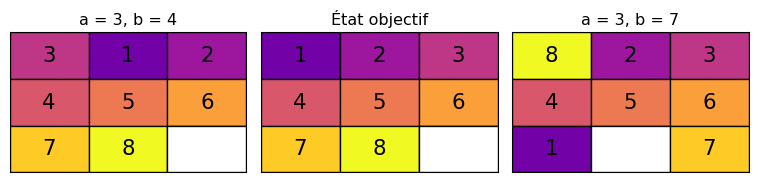

où

-   **a** = distance des tuiles mal placées
-   **b** = distance de Manhattan

`misplaced_tiles_distance` ne tient pas compte de la distance d’une
tuile par rapport à sa position finale prévue, tandis que
`manhattan_distance` le fait.

Ainsi, on peut s’attendre à ce que l’algorithme utilisant la distance de
Manhattan sélectionne le prochain nœud à explorer de manière plus
judicieuse.

## Recherche du meilleur d’abord

In [22]:
def best_first_search_revised(initial_state, goal_state):
    frontier = [] # Initialiser la file de priorité
    initial_h = manhattan_distance(initial_state, goal_state)
    # Ajouter l'état initial avec sa valeur heuristique dans la file
    heapq.heappush(frontier, (initial_h, 0, initial_state, [])) # (f(n), g(n), état, chemin)

    explored = set()

    iterations = 0

    while not is_empty(frontier):
        f, g, current_state, path = heapq.heappop(frontier)

        if is_goal(current_state, goal_state):
            print(f"Nombre d'itérations : {iterations}")
            return path + [current_state] # Retourner le chemin réussi

        iterations = iterations + 1

        explored.add(tuple(current_state))

        for neighbor in expand(current_state):
            if tuple(neighbor) not in explored:
                new_g = g + 1 # Incrémenter le coût du chemin
                h = manhattan_distance(neighbor, goal_state)
                new_f = new_g + h # Calculer le nouveau coût total
                # Ajouter l'état voisin dans la file de priorité
                heapq.heappush(frontier, (new_f, new_g, neighbor, path + [current_state]))
                explored.add(tuple(neighbor)) # Marquer le voisin comme exploré

    return None # Aucune solution trouvée

Lors de l’expansion d’un nœud dans l’arbre de recherche, il est crucial
de noter que nous n’évaluons pas immédiatement ses nœuds descendants
pour déterminer s’ils sont des nœuds objectifs. Au lieu de cela, ces
descendants sont ajoutés à la frontière, qui est une file de priorité.
Cela permet de comparer leurs valeurs $f(n)$ avec celles des autres
nœuds dans la frontière, garantissant que les nœuds les plus prometteurs
sont considérés en premier en fonction de leur coût total estimé.

Par conséquent, il est possible que la frontière inclue des nœuds qui
sont des nœuds objectifs. Cependant, leurs valeurs $f(n)$ peuvent être
plus élevées que celles d’autres nœuds jugés plus prometteurs, car ces
autres nœuds pourraient mener à un chemin plus court vers l’objectif.

## Cas simple

Nombre d'itérations : 2

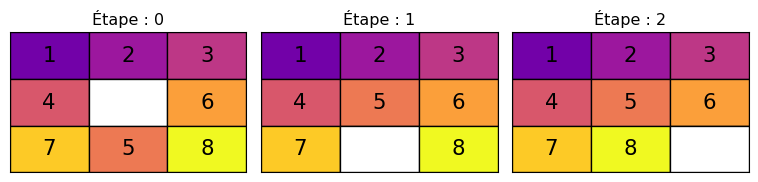

In [24]:
initial_state_8 = [1, 2, 3,
                   4, 0, 6,
                   7, 5, 8]

goal_state_8 = [1, 2, 3,
                4, 5, 6,
                7, 8, 0]

best_first_search_revised(initial_state_8, goal_state_8)

Nombre d'itérations : 2

[[1, 2, 3, 4, 0, 6, 7, 5, 8],
 [1, 2, 3, 4, 5, 6, 7, 0, 8],
 [1, 2, 3, 4, 5, 6, 7, 8, 0]]

## Cas difficile

In [25]:
initial_state_8 = [6, 4, 5,
                   8, 2, 7,
                   1, 0, 3]

goal_state_8 = [1, 2, 3,
                4, 5, 6,
                7, 8, 0]

print("Résolution du 8-Puzzle avec best_first_search...")

solution_8_bfs = best_first_search_revised(initial_state_8, goal_state_8)

if solution_8_bfs:
    print(f"Solution best_first_search trouvée en {len(solution_8_bfs) - 1} mouvements :")
    print_solution(solution_8_bfs)
else:
    print("Aucune solution trouvée pour le 8-Puzzle en utilisant best_first_search.")

Résolution du 8-Puzzle avec best_first_search...
Nombre d'itérations : 2255
Solution best_first_search trouvée en 25 mouvements :
Étape 0 :
6 4 5
8 2 7
1   3

Étape 1 :
6 4 5
8 2 7
  1 3

Étape 2 :
6 4 5
  2 7
8 1 3

Étape 3 :
6 4 5
2   7
8 1 3

Étape 4 :
6   5
2 4 7
8 1 3

Étape 5 :
  6 5
2 4 7
8 1 3

Étape 6 :
2 6 5
  4 7
8 1 3

Étape 7 :
2 6 5
4   7
8 1 3

Étape 8 :
2 6 5
4 1 7
8   3

Étape 9 :
2 6 5
4 1 7
  8 3

Étape 10 :
2 6 5
  1 7
4 8 3

Étape 11 :
2 6 5
1   7
4 8 3

Étape 12 :
2 6 5
1 7  
4 8 3

Étape 13 :
2 6 5
1 7 3
4 8  

Étape 14 :
2 6 5
1 7 3
4   8

Étape 15 :
2 6 5
1   3
4 7 8

Étape 16 :
2   5
1 6 3
4 7 8

Étape 17 :
2 5  
1 6 3
4 7 8

Étape 18 :
2 5 3
1 6  
4 7 8

Étape 19 :
2 5 3
1   6
4 7 8

Étape 20 :
2   3
1 5 6
4 7 8

Étape 21 :
  2 3
1 5 6
4 7 8

Étape 22 :
1 2 3
  5 6
4 7 8

Étape 23 :
1 2 3
4 5 6
  7 8

Étape 24 :
1 2 3
4 5 6
7   8

Étape 25 :
1 2 3
4 5 6
7 8  


## 1000 Expériences

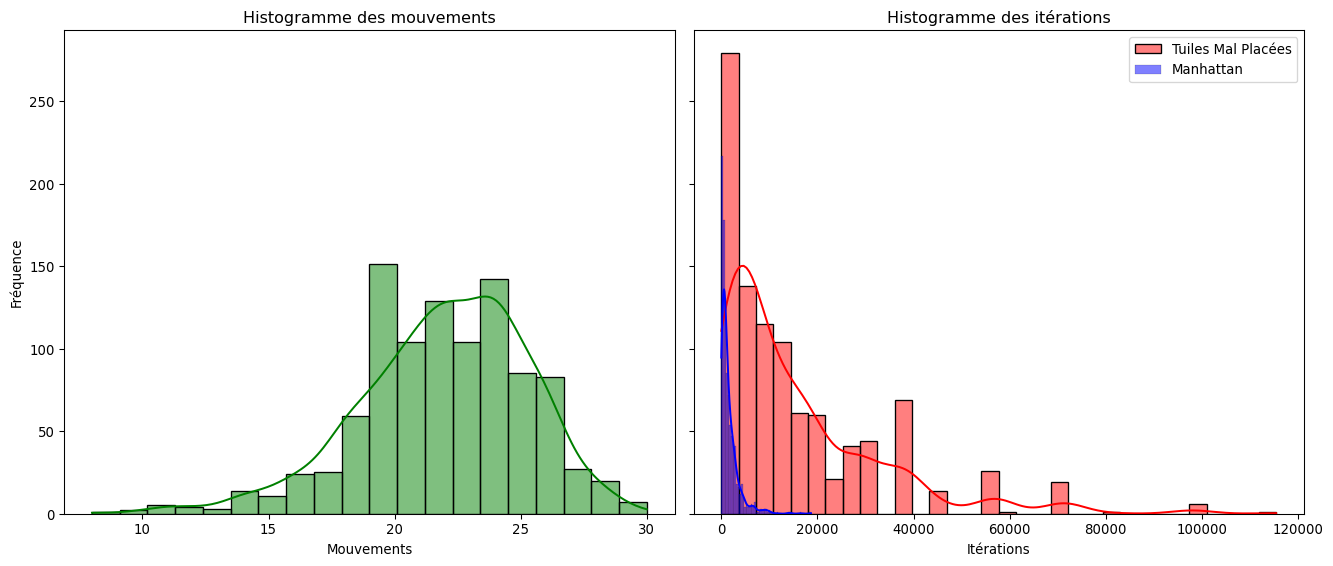

## Diagramme de dispersion

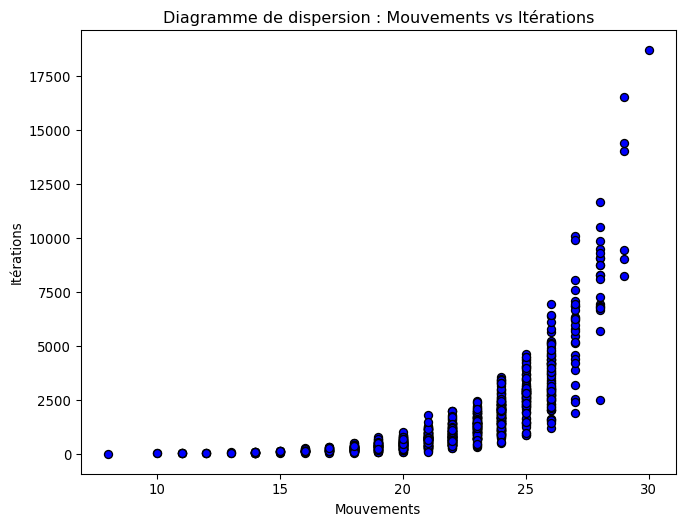

(Manhattan)

## Exploration

La recherche en largeur (BFS) garantit de trouver le chemin le plus
court, ou la solution de coût le plus bas, en supposant que toutes les
actions ont un coût unitaire.

Développez un programme qui effectue les tâches suivantes :

1.  Générer une configuration aléatoire du puzzle 8-Puzzle.
2.  Déterminer le chemin le plus court en utilisant la recherche en
    largeur.
3.  Identifier la solution optimale en utilisant l’algorithme $A^\star$.
4.  Comparer les coûts des solutions obtenues aux étapes 2 et 3. Il ne
    devrait pas y avoir de différence si $A^\star$ identifie des
    solutions optimales en termes de coût.
5.  Répéter le processus.

## Exploration

L’heuristique $h(n) = 0$ est considérée comme admissible, mais elle
entraîne généralement une exploration inefficace de l’espace de
recherche. Développez un programme pour explorer ce concept. Montrez
que, lorsque toutes les actions sont supposées avoir un coût unitaire,
$A^\star$ et la recherche en largeur (BFS) explorent l’espace de
recherche de manière similaire. Plus précisément, ils examinent d’abord
tous les chemins de longueur un, puis ceux de longueur deux, et ainsi de
suite.

## Remarques

-   La **recherche en largeur (BFS)** identifie la solution optimale, 25
    mouvements, en 145 605 itérations.

-   La **recherche en profondeur (DFS)** découvre une solution
    impliquant 1 157 mouvements en 1 187 itérations.

-   La **recherche du meilleur d’abord** identifie la solution optimale,
    25 mouvements, en 2 255 itérations.

## Évaluation de la performance

-   **Complétude** : L’algorithme assure-t-il qu’une solution sera
    trouvée si elle existe et indique-t-il correctement l’absence de
    solution lorsqu’aucune solution n’existe ?

-   **Optimalité du coût** : L’algorithme identifie-t-il la solution
    avec le **coût de chemin le plus bas** parmi toutes les solutions
    possibles ?

-   Les trois algorithmes sont-ils complets ? Quelles sont les
    conditions nécessaires ?

-   Tous les trois algorithmes garantissent-ils l’optimalité du coût ?

## Évaluation de la performance

-   **Complexité temporelle** : Comment le **temps** requis par
    l’algorithme évolue-t-il par rapport au **nombre d’états** et
    d’**actions** ?

-   **Complexité spatiale** : Comment l’**espace** requis par
    l’algorithme évolue-t-il par rapport au **nombre d’états** et
    d’**actions** ?

Alternativement, la complexité peut être évaluée en fonction de la
**profondeur** ($d$) et du **facteur de branchement** ($b$) de l’arbre
de recherche, plutôt qu’en fonction du nombre d’états (nœuds) et
d’actions (arêtes) dans l’espace d’états.

## Vidéos par Sebastian Lague

-   [A\* Pathfinding (E01 : explication de
    l’algorithme)](https://www.youtube.com/watch?v=-L-WgKMFuhE) publié
    le 2014-12-16.
-   [A\* Pathfinding (E02 : grille de
    nœuds)](https://www.youtube.com/watch?v=nhiFx28e7JY) publié le
    2014-12-18.
-   [A\* Pathfinding (E03 : implémentation de
    l’algorithme)](https://www.youtube.com/watch?v=mZfyt03LDH4) publié
    le 2014-12-19.
-   [A\* Pathfinding (E04 : optimisation du
    tas)](https://www.youtube.com/watch?v=3Dw5d7PlcTM) publié le
    2014-12-24.
-   [A\* Pathfinding (E05 :
    unités)](https://www.youtube.com/watch?v=dn1XRIaROM4) publié le
    2015-01-06.
-   [A\* Pathfinding (E06 :
    poids)](https://www.youtube.com/watch?v=T0Qv4-KkAUo) publié le
    2015-01-11.
-   [A\* Pathfinding (E07 : poids
    lissés)](https://www.youtube.com/watch?v=Tb-rM3wGwv4) publié le
    2016-12-30.
-   [A\* Pathfinding (E08 : lissage de chemin
    1/2)](https://www.youtube.com/watch?v=NjQjl-ZBXoY) publié le
    2017-01-31.
-   [A\* Pathfinding (E09 : lissage de chemin
    2/2)](https://www.youtube.com/watch?v=bfevcsANSr4) publié le
    2017-01-31.
-   [A\* Pathfinding (E10 :
    threading)](https://www.youtube.com/watch?v=TFyEWDMQUKc) publié le
    2017-02-03.
-   [Tutoriel A\* Pathfinding
    (Unity)](https://www.youtube.com/playlist?list=PLFt_AvWsXl0cq5Umv3pMC9SPnKjfp9eGW)
    (liste de lecture)

## Une ressource dédiée à $A^\star$

-   [Amit’s A\*
    Pages](http://theory.stanford.edu/~amitp/GameProgramming/)

# Prologue

## Résumé

-   Recherche informée et heuristiques
-   Recherche du meilleur d’abord
-   Implémentations

-   **Recherche informée et heuristiques :**
    -   Introduit le concept de **fonctions heuristiques** (`h(n)`) pour
        estimer les coûts.
    -   **Recherche du meilleur d’abord :**
        -   Utilise des heuristiques pour prioriser les nœuds qui
            semblent plus proches de l’objectif.
        -   Implémenté avec une file de priorité triée par coût estimé.
    -   **Heuristique de distance de Manhattan :**
        -   Calcule la somme des distances des tuiles par rapport à
            leurs positions cibles.
        -   Utilisé dans le 8-Puzzle pour guider la recherche plus
            efficacement.
-   **Analyse comparative :**
    -   **BFS :** Solution optimale en 145 605 itérations (25
        mouvements).
    -   **DFS :** Solution sous-optimale en 1 187 itérations (1 157
        mouvements).
    -   **Recherche du meilleur d’abord :** Solution optimale en 2 255
        itérations (25 mouvements).
    -   Démontré que les algorithmes de recherche informée peuvent
        trouver des solutions optimales plus efficacement.

## Prochaine conférence

-   Nous explorerons plus en détail les fonctions heuristiques et
    examinerons d’autres algorithmes de recherche.

## Références

Hart, Peter E., Nils J. Nilsson, et Bertram Raphael. 1968. « A Formal
Basis for the Heuristic Determination of Minimum Cost Paths ». *IEEE
Transactions on Systems Science and Cybernetics* 4 (2): 100‑107.
<https://doi.org/10.1109/tssc.1968.300136>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa